## Exercise 02 : Bar

In [1]:
import pandas as pd
import sqlite3

### Make a connection to the database

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

### Run query

In [3]:
query = """
SELECT
   uid, DATETIME(timestamp) AS commits
FROM checker
WHERE uid LIKE 'user%';
"""
df = pd.read_sql(sql=query, con=conn, parse_dates='commits')
df

,uid,commits
0,user_4,2020-04-17 05:19:02
1,user_4,2020-04-17 05:22:35
2,user_4,2020-04-17 05:22:45
3,user_4,2020-04-17 05:34:14
4,user_4,2020-04-17 05:34:24
...,...,...
3202,user_1,2020-05-21 20:19:06
3203,user_1,2020-05-21 20:22:41
3204,user_1,2020-05-21 20:22:41
3205,user_1,2020-05-21 20:37:00


### Add daytime column from commits time

In [4]:
df['daytime'] = pd.cut(x=df['commits'].dt.hour,
                       bins=[0, 4, 10, 17, 24],
                       labels=['night', 'morning', 'afternoon', 'evening'],
                       right=False, include_lowest=True)
df['date'] = df['commits'].dt.date
df

,uid,commits,daytime,date
0,user_4,2020-04-17 05:19:02,morning,2020-04-17
1,user_4,2020-04-17 05:22:35,morning,2020-04-17
2,user_4,2020-04-17 05:22:45,morning,2020-04-17
3,user_4,2020-04-17 05:34:14,morning,2020-04-17
4,user_4,2020-04-17 05:34:24,morning,2020-04-17
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06,evening,2020-05-21
3203,user_1,2020-05-21 20:22:41,evening,2020-05-21
3204,user_1,2020-05-21 20:22:41,evening,2020-05-21
3205,user_1,2020-05-21 20:37:00,evening,2020-05-21


In [5]:
df = df.groupby(["date", 'daytime'], observed=False).size().unstack()
df

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


In [6]:
len(df)

35

### Create a bar chart

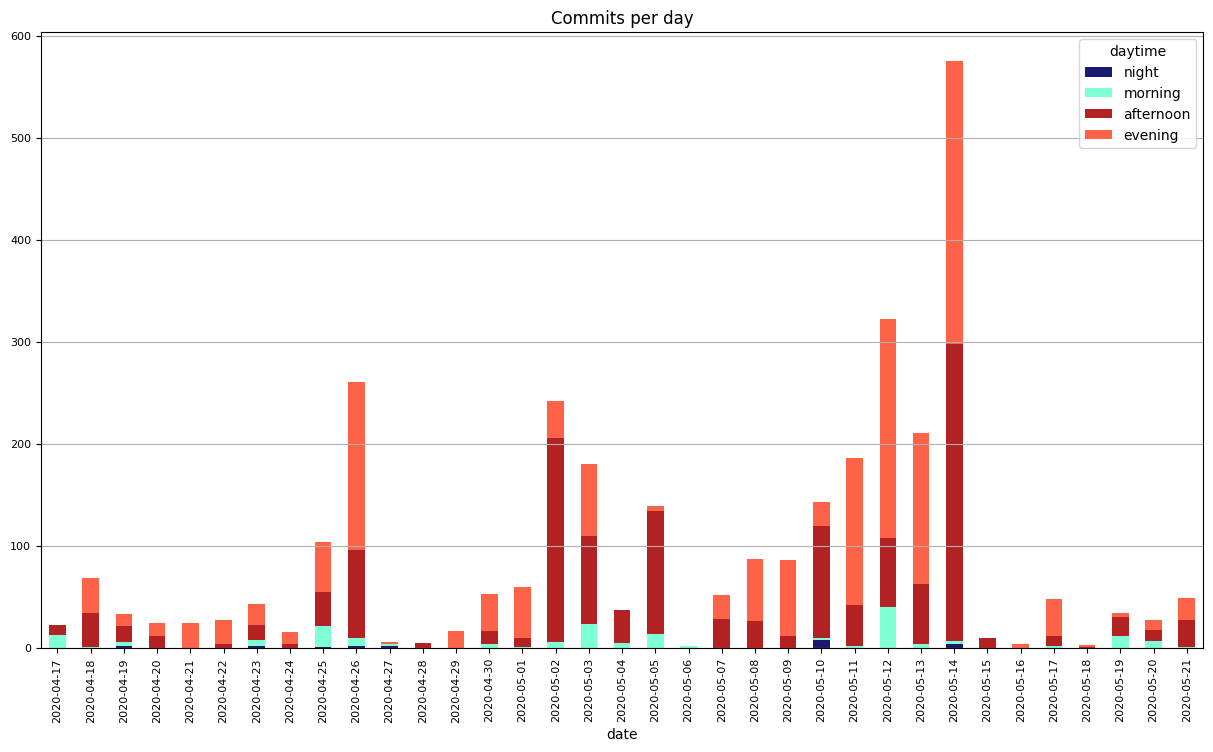

In [7]:
bar_chart = df.plot(
    kind='bar',
    use_index=True,
    y = ['night', 'morning', 'afternoon', 'evening'],
    figsize=(15, 8),
    title='Commits per day',
    rot=90,
    fontsize=8,
    stacked=True,
    grid=True,
    legend=True,
    color=['MidnightBlue', 'Aquamarine', 'FireBrick', 'Tomato']
)
bar_chart.grid(axis='x')

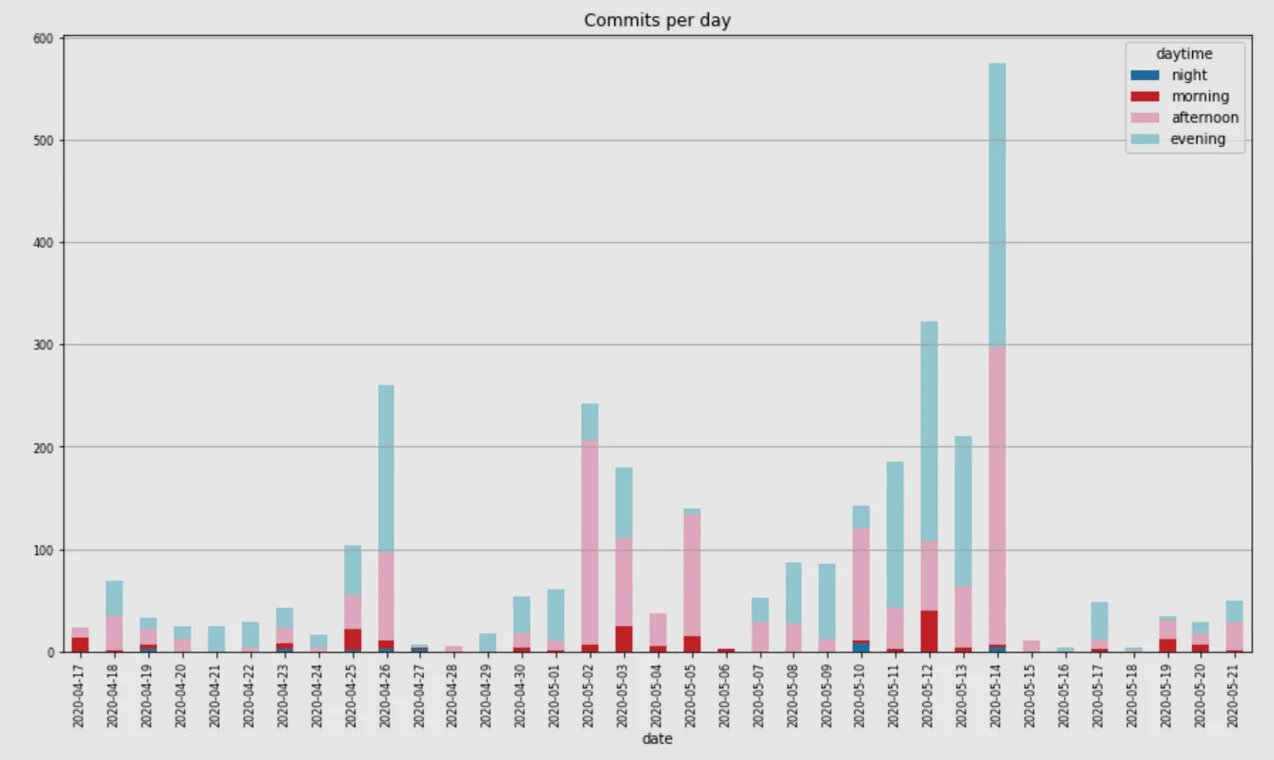

In [8]:
conn.close()

### “When do our users usually commit the labs: in the night, morning, afternoon, or evening?”

#### Afternoon and evening

### "Which day has the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon?"

#### 2020.05.12